# 📊 Riset & Eksplorasi Data Engagement Media Sosial
## Analisis Komparatif: Metode Invers Weight V1 (Mba Ocim) vs V2 (Smoothed Invers Weight)

Notebook ini menyajikan analisis komprehensif terhadap dataset media sosial 6 platform (**Twitter/X, Instagram, TikTok, YouTube, Threads, Facebook**) yang diambil dari Elasticsearch SMM:
1. **Eksplorasi Data (EDA)**: Distribusi metrik interaksi, analisis zero-inflation, dan karakteristik engagement per platform.
2. **Kalkulasi Metode V1**: Formula dasar Inverse Document Frequency ($IDF = \log_2 \frac{N}{DF}$) tanpa smoothing.
3. **Kalkulasi Metode V2**: Formula Invers Weight dengan Add-$\alpha$ smoothing dan granularitas per-platform ($IDF_{p,f} = \log_2 \frac{N_p + \alpha}{DF_{p,f} + \alpha}$).
4. **Uji Korelasi Statistik**: Korelasi Pearson & Spearman antar faktor engagement di masing-masing platform dan korelasi antar skor (V1 vs V2 vs Raw Engagement).
5. **Analisis Perbandingan Ranking & Top Posts**: Evaluasi dampak pembobotan terhadap urutan postingan teratas.


## 1. Setup Environment & Import Libraries


In [1]:
import os
import sys
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Konfigurasi Tampilan Visualisasi
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
sns.set_palette("tab10")

print("Library dan konfigurasi visualisasi berhasil dimuat!")


Library dan konfigurasi visualisasi berhasil dimuat!


## 2. Load Dataset Hasil Crawling / Merging

Dataset dimuat dari direktori `data/<index>/`. Dataset mencakup 6 platform dengan 1.000 data per platform (total 6.000 dokumen).


In [2]:
# Path ke file dataset
base_dir = Path.cwd()
search_dirs = [base_dir / "data", base_dir / "pengolahan_data" / "data", base_dir]

parquet_files = []
csv_files = []
for d in search_dirs:
    if d.exists():
        parquet_files.extend(list(d.rglob("dataset_with_engagement_scores.parquet")))
        parquet_files.extend(list(d.rglob("merged_all_platforms.parquet")))
        csv_files.extend(list(d.rglob("dataset_with_engagement_scores.csv")))
        csv_files.extend(list(d.rglob("merged_all_platforms.csv")))

if parquet_files:
    dataset_path = parquet_files[0]
    df = pd.read_parquet(dataset_path)
    print(f"[INFO] Memuat dataset dari Parquet: {dataset_path}")
elif csv_files:
    dataset_path = csv_files[0]
    df = pd.read_csv(dataset_path)
    print(f"[INFO] Memuat dataset dari CSV: {dataset_path}")
else:
    raise FileNotFoundError("File dataset tidak ditemukan. Jalankan run_pipeline.py terlebih dahulu.")

print(f"[INFO] Dimensi Dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"[INFO] Platform dalam dataset: {df['platform'].unique().tolist()}")
df.head(3)


[INFO] Memuat dataset dari Parquet: d:\SPECTRA\Riset_enggagement\pengolahan_data\data\smm-data-hot-20260804\dataset_with_engagement_scores.parquet
[INFO] Dimensi Dataset: 6,000 baris x 30 kolom
[INFO] Platform dalam dataset: ['twitter', 'instagram', 'tiktok', 'youtube', 'threads', 'facebook']


,id,platform,username,user_id,user_full_name,text,created_at,hour,dayname,post_url,...,is_repost,engagements_raw,watch_ratio,llm_flag,content_type,sub_type,created_at_dt,engagement_score_v1,engagement_score_v2,engagement_score_v2_log
0,2084488553124319262,twitter,iOutatime,1366058496,Mason Fowlkes,"RT @SawyerMerritt: SpaceX says that ""by the en...",2026-08-04 03:56:13,10,tuesday,https://twitter.com/iOutatime/status/208448855...,...,True,0.0,0.0,True,twitter-post,retweet,2026-08-04 03:56:13,0.0,0.0,0.0
1,2084494126461177939,twitter,KiLEn86767873,1242428386732953601,K i L E n x BB97,RT @BamBamBooster: 260804 | ©️haier_thailand’s...,2026-08-04 04:18:22,11,tuesday,https://twitter.com/KiLEn86767873/status/20844...,...,True,0.0,0.0,True,twitter-post,retweet,2026-08-04 04:18:22,0.0,0.0,0.0
2,2084489662706618853,twitter,floirework,796607700398436352,abiljuga,"RT @LBH_Jakarta: ALERTA! ALERTA!\n\nHari ini, ...",2026-08-04 04:00:38,11,tuesday,https://twitter.com/floirework/status/20844896...,...,True,0.0,0.0,True,twitter-post,retweet,2026-08-04 04:00:38,0.0,0.0,0.0


## 3. Exploratory Data Analysis (EDA) per Platform

Mari kita telusuri volume postingan, ringkasan statistik metrik engagement, dan distribusi interaksi di tiap platform.


In [3]:
# 3.1 Distribusi Jumlah Post per Platform
platform_counts = df['platform'].value_counts()
print("Jumlah Dokumen per Platform:")
print(platform_counts)

# 3.2 Ringkasan Metrik Engagement per Platform
metrics = ['likes_count', 'reply_count', 'shares_count', 'views_count', 'quotes_count', 'repost_count', 'bookmark_count']
available_metrics = [m for m in metrics if m in df.columns]

summary_df = df.groupby('platform')[available_metrics].agg(['mean', 'median', 'max'])
summary_df


Jumlah Dokumen per Platform:
platform
twitter      1000
instagram    1000
tiktok       1000
youtube      1000
threads      1000
facebook     1000
Name: count, dtype: int64


likes_count               reply_count              shares_count  \
                 mean median    max        mean median   max         mean   
platform                                                                    
facebook      207.148    4.0  32841      21.566    0.0  6236        5.761   
instagram      11.268    0.0   4727       2.496    0.0  2071        0.000   
threads        15.633    0.0   2479       4.267    0.0   398        1.137   
tiktok        104.860    0.0  16452       4.145    0.0   336        6.414   
twitter         0.887    0.0    299       0.081    0.0    24        0.154   
youtube        15.878    0.0   3729       2.871    0.0   482        0.000   

                       views_count  ...         quotes_count             \
          median   max        mean  ...     max         mean median max   
platform                            ...                                   
facebook     0.0  1103       0.000  ...       0         0.00    0.0   0   
instagram    0.0     0       0.000  ...       0         0.00    0.0   0   
threads      0.0   302       0.000  ...       0         0.07    0.0  28   
tiktok       0.0  2106    1845.977  ...  205269         0.00    0.0   0   
twitter      0.0    65      99.553  ...   81529         0.00    0.0   0   
youtube      0.0     0     458.054  ...   76547         0.00    0.0   0   

          repost_count             bookmark_count             
                  mean median  max           mean median max  
platform                                                      
facebook         0.000    0.0    0            0.0    0.0   0  
instagram        0.000    0.0    0            0.0    0.0   0  
threads          0.764    0.0  173            0.0    0.0   0  
tiktok           0.000    0.0    0            0.0    0.0   0  
twitter          0.000    0.0    0            0.0    0.0   0  
youtube          0.000    0.0    0            0.0    0.0   0  

[6 rows x 21 columns]

### 3.3 Visualisasi Distribusi Metrik Engagement (Log-Scale)
Karena metrik media sosial umumnya bersifat *heavy-tailed / power-law* (beberapa post viral memiliki engagement luar biasa tinggi sementara mayoritas kecil), kita gunakan transformasi log-scale $\log_{10}(1 + x)$.


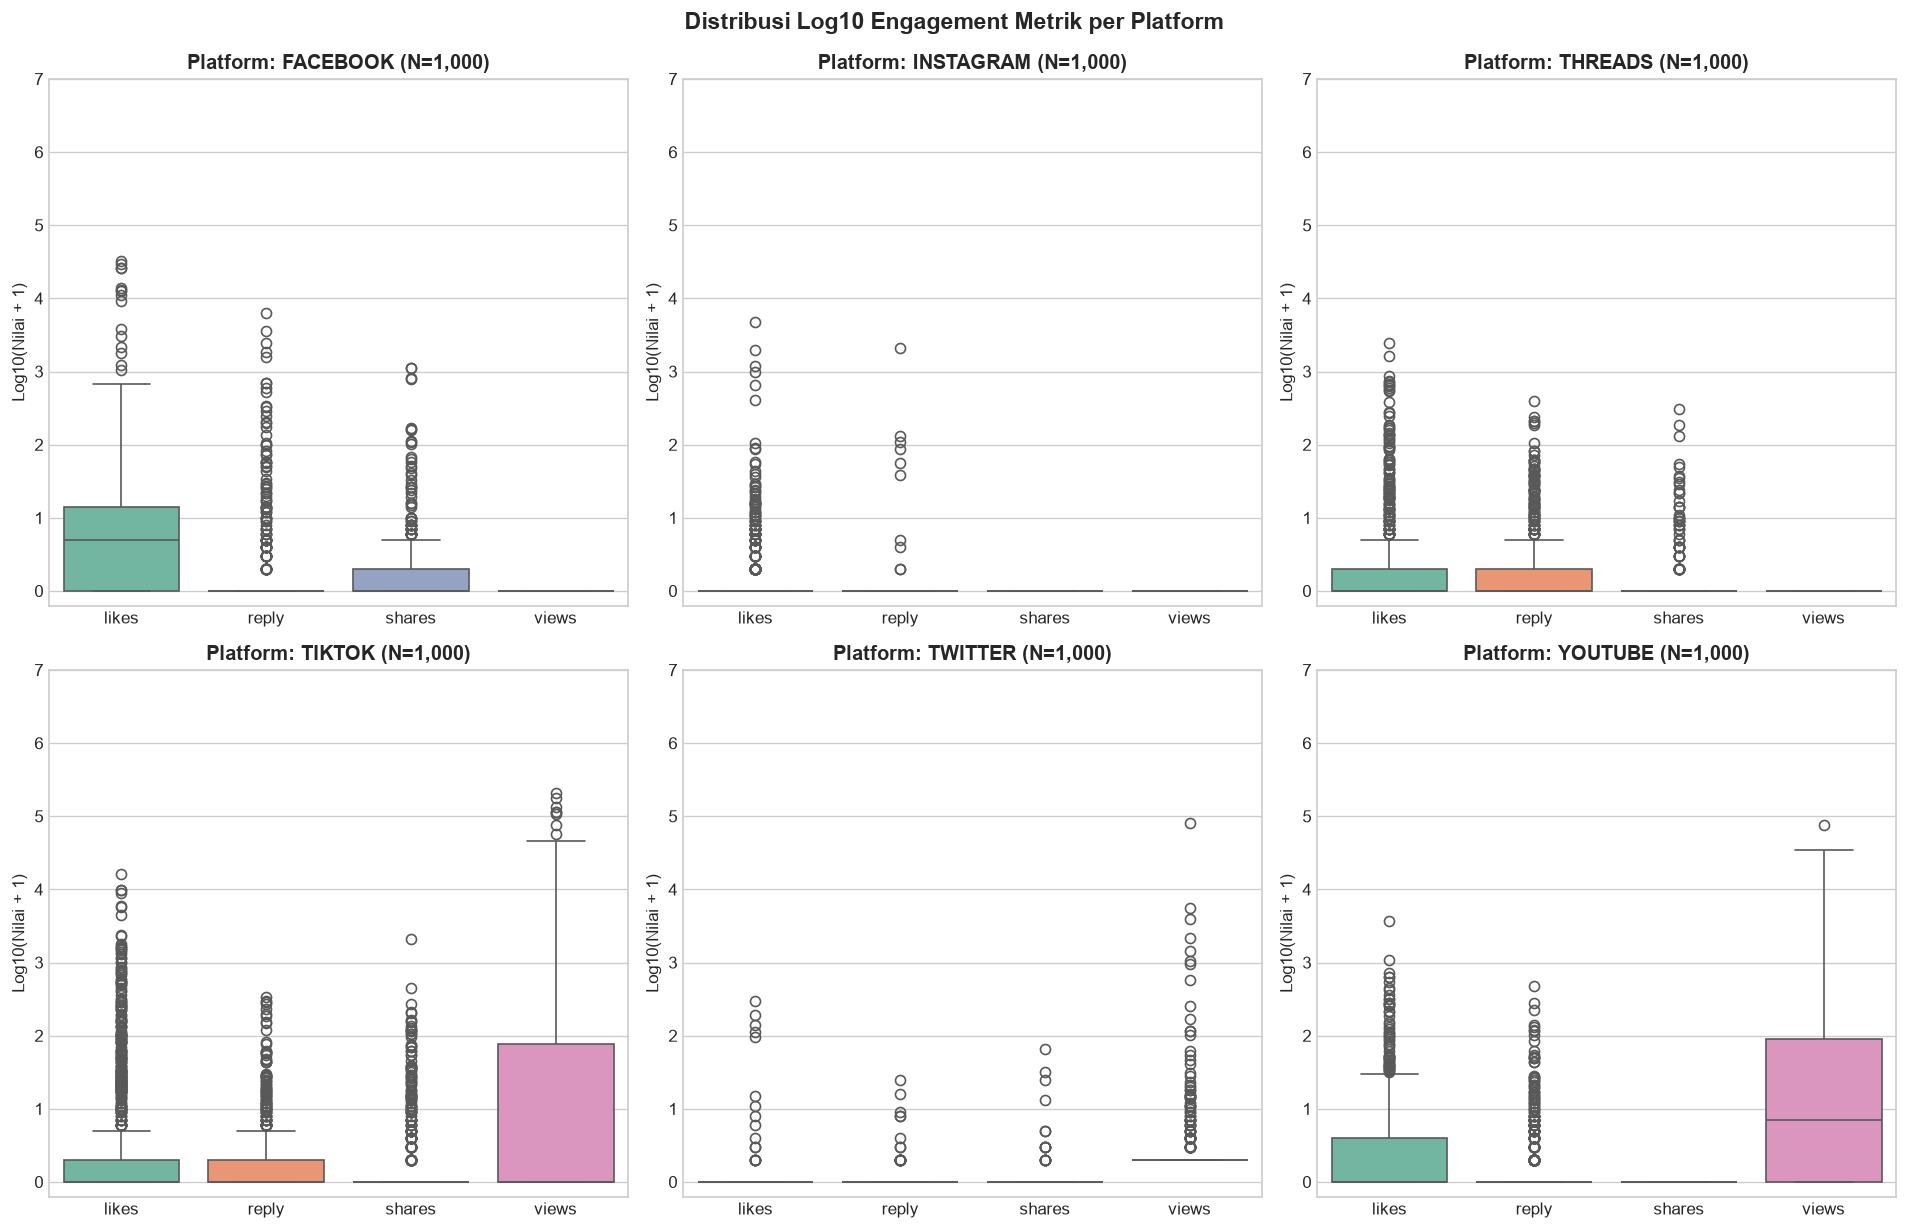

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

platforms = sorted(df['platform'].unique())
for idx, p in enumerate(platforms):
    ax = axes[idx]
    sub_df = df[df['platform'] == p]
    
    plot_data = pd.DataFrame()
    for m in ['likes_count', 'reply_count', 'shares_count', 'views_count']:
        if m in sub_df.columns:
            plot_data[m.replace('_count', '')] = np.log10(sub_df[m].fillna(0).clip(lower=0) + 1)
            
    sns.boxplot(data=plot_data, ax=ax, palette='Set2')
    ax.set_title(f"Platform: {p.upper()} (N={len(sub_df):,})", fontweight='bold')
    ax.set_ylabel("Log10(Nilai + 1)")
    ax.set_ylim(-0.2, 7)

plt.tight_layout()
plt.suptitle("Distribusi Log10 Engagement Metrik per Platform", y=1.02, fontsize=14, fontweight='bold')
plt.show()


### 3.4 Analisis Zero-Inflation (% Postingan dengan Nilai 0)
Salah satu alasan utama mengapa V2 membutuhkan Add-$\alpha$ smoothing adalah tingginya proporsi dokumen yang memiliki engagement = 0 pada faktor tertentu.


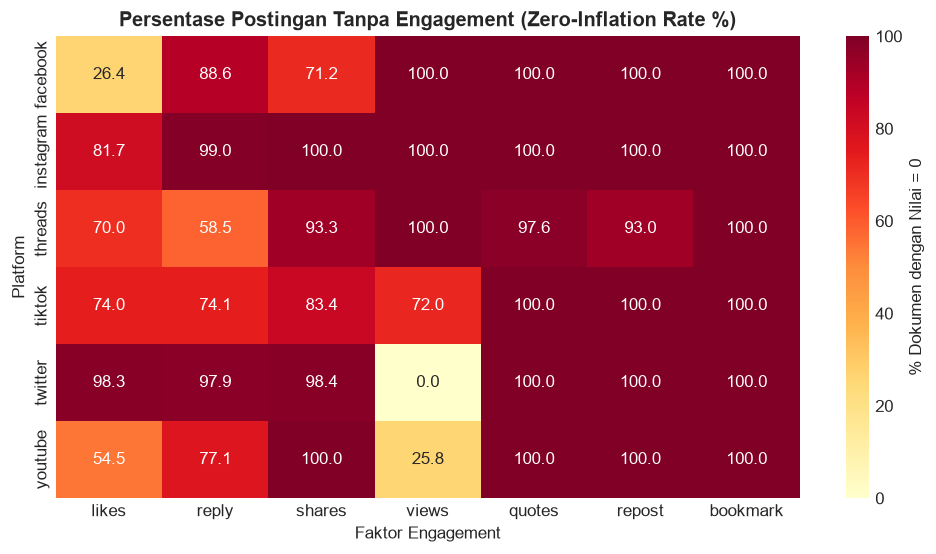

In [5]:
zero_pct_list = []
for p in platforms:
    sub = df[df['platform'] == p]
    row = {'platform': p}
    for m in available_metrics:
        zero_pct = (sub[m].fillna(0) == 0).mean() * 100
        row[m.replace('_count', '')] = round(zero_pct, 1)
    zero_pct_list.append(row)

df_zero_inflation = pd.DataFrame(zero_pct_list).set_index('platform')

plt.figure(figsize=(10, 5))
sns.heatmap(df_zero_inflation, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': '% Dokumen dengan Nilai = 0'})
plt.title("Persentase Postingan Tanpa Engagement (Zero-Inflation Rate %)", fontweight='bold', fontsize=12)
plt.ylabel("Platform")
plt.xlabel("Faktor Engagement")
plt.show()


## 4. Implementasi & Perhitungan Metode V1 (Invers Weight Mba Ocim)

### Formula V1:
$$N_f = \frac{\sum \text{Faktor}_f}{\text{Timeframe (Hari)}}, \quad DF = \text{Total Post dalam Timeframe}$$
$$IDF_f = \log_2\left(\frac{N_f}{DF}\right)$$
$$\text{Engagement Score V1} = \sum_{f \in \text{Faktor}(p)} (\text{Nilai Faktor}_f \times IDF_f)$$

### Faktor per Platform pada V1:
- **Facebook**: Likes, Comment (`reply_count`), Shares (`shares_count`)
- **Twitter**: Likes, Reply, Retweet (`shares_count`)
- **Instagram**: Likes, Reply
- **TikTok**: Likes, Shares, Comment (`reply_count`), Play Count (`views_count`)
- **YouTube**: Likes, Reply, View (`views_count`) *(Dislike dropped)*
- **Threads**: Likes, Reply, Repost, Quote, Shares


In [6]:
FACTORS_V1 = {
    "facebook": ["likes_count", "reply_count", "shares_count"],
    "twitter": ["likes_count", "reply_count", "shares_count"],
    "instagram": ["likes_count", "reply_count"],
    "tiktok": ["likes_count", "shares_count", "reply_count", "views_count"],
    "youtube": ["likes_count", "reply_count", "views_count"],
    "threads": ["likes_count", "reply_count", "repost_count", "quotes_count", "shares_count"]
}

# 1. Hitung Timeframe (hari)
timeframe_days = 1.0
if 'created_at' in df.columns:
    ts = pd.to_datetime(df['created_at'], errors='coerce').dropna()
    if len(ts) >= 2:
        diff_days = (ts.max() - ts.min()).total_seconds() / (24 * 3600)
        if diff_days >= 1.0:
            timeframe_days = diff_days

total_posts_v1 = len(df)
print(f"Timeframe: {timeframe_days:.2f} hari | Total Posts DF: {total_posts_v1:,}")

# 2. Hitung N_f dan IDF_f Global
all_v1_factors = sorted(list(set([f for sub in FACTORS_V1.values() for f in sub])))
weights_v1 = {}

v1_records = []
for factor in all_v1_factors:
    total_val = df[factor].fillna(0).sum() if factor in df.columns else 0
    n_val = total_val / timeframe_days
    ratio = (n_val / total_posts_v1) if total_posts_v1 > 0 else 0
    idf = math.log2(ratio) if ratio > 0 else 0.0
    weights_v1[factor] = idf
    v1_records.append({
        "Faktor": factor,
        "Total Kemunculan": int(total_val),
        "N (Rata-rata/Hari)": round(n_val, 2),
        "DF (Total Post)": total_posts_v1,
        "Ratio (N/DF)": round(ratio, 4),
        "Bobot IDF V1": round(idf, 4)
    })

df_v1_weights = pd.DataFrame(v1_records)
display(df_v1_weights)

# 3. Hitung Skor V1 untuk tiap baris
def calculate_score_v1(row):
    p = str(row.get('platform', '')).lower()
    factors = FACTORS_V1.get(p, [])
    score = 0.0
    for f in factors:
        val = row.get(f, 0)
        if pd.notna(val) and val > 0:
            score += float(val) * weights_v1.get(f, 0.0)
    return score

df['calc_score_v1'] = df.apply(calculate_score_v1, axis=1)
print("[OK] Skor V1 berhasil dihitung!")


Timeframe: 1.00 hari | Total Posts DF: 6,000


,Faktor,Total Kemunculan,N (Rata-rata/Hari),DF (Total Post),Ratio (N/DF),Bobot IDF V1
0,likes_count,355674,355674.0,6000,59.2790,5.8894
1,quotes_count,70,70.0,6000,0.0117,-6.4215
2,reply_count,35426,35426.0,6000,5.9043,2.5618
3,repost_count,764,764.0,6000,0.1273,-2.9733
4,shares_count,13466,13466.0,6000,2.2443,1.1663
5,views_count,2403584,2403584.0,6000,400.5973,8.6460


[OK] Skor V1 berhasil dihitung!


## 5. Implementasi & Perhitungan Metode V2 (New Invers Weight with Add-$\alpha$ Smoothing)

### Formula V2:
$$N_p = \text{Total post di platform } p$$
$$DF_{p,f} = |\{ \text{post} \in p \mid \text{Faktor}_f > 0 \}|$$
$$IDF_{p,f} = \log_2\left( \frac{N_p + \alpha}{DF_{p,f} + \alpha} \right)$$
$$\text{Engagement Score V2} = \sum_{f \in \text{Faktor}(p)} (\text{Nilai Faktor}_f \times IDF_{p,f})$$

### Keunggulan V2:
1. **Granularitas per Platform**: Bobot dihitung terpisah untuk masing-masing platform, sehingga skala interaksi tidak tercampur.
2. **Smoothing Add-$\alpha$**: Mencegah pembagian dengan nol atau $\log_2(0)$ pada faktor langka.
3. **Definisi DF Presisi**: Mengukur jumlah dokumen yang *aktif* memiliki interaksi tersebut ($> 0$).


In [7]:
FACTORS_V2 = {
    "facebook": ["shares_count", "likes_count", "reply_count"],
    "twitter": ["shares_count", "views_count", "reply_count", "likes_count", "quotes_count", "bookmark_count"],
    "instagram": ["shares_count", "reply_count", "likes_count", "repost_count"],
    "tiktok": ["shares_count", "views_count", "reply_count", "likes_count", "repost_count", "bookmark_count"],
    "youtube": ["shares_count", "views_count", "reply_count", "likes_count"],
    "threads": ["shares_count", "repost_count", "quotes_count", "reply_count", "likes_count"]
}

alpha = 1.0  # Laplace smoothing constant

weights_v2 = {}
v2_records = []

for p, factors in FACTORS_V2.items():
    sub_df = df[df['platform'] == p]
    n_p = len(sub_df)
    weights_v2[p] = {}
    
    for f in factors:
        if f in sub_df.columns:
            df_pf = (sub_df[f].fillna(0) > 0).sum()
        else:
            df_pf = 0
            
        num = n_p + alpha
        den = df_pf + alpha
        idf_v2 = math.log2(num / den)
        idf_v2 = max(0.0, idf_v2)  # Clamping >= 0
        
        weights_v2[p][f] = idf_v2
        v2_records.append({
            "Platform": p,
            "Faktor": f,
            "N_p (Total Post)": n_p,
            "DF_p,f (Post > 0)": df_pf,
            "DF Rate (%)": round((df_pf / n_p * 100) if n_p > 0 else 0, 1),
            "Bobot IDF V2": round(idf_v2, 4)
        })

df_v2_weights = pd.DataFrame(v2_records)
display(df_v2_weights.head(15))

# 4. Hitung Skor V2 untuk tiap baris
def calculate_score_v2(row):
    p = str(row.get('platform', '')).lower()
    factors = FACTORS_V2.get(p, [])
    p_weights = weights_v2.get(p, {})
    score = 0.0
    for f in factors:
        val = row.get(f, 0)
        if pd.notna(val) and val > 0:
            score += float(val) * p_weights.get(f, 0.0)
    return score

df['calc_score_v2'] = df.apply(calculate_score_v2, axis=1)
df['calc_score_v2_log'] = np.log1p(df['calc_score_v2'])
print("[OK] Skor V2 berhasil dihitung!")


,Platform,Faktor,N_p (Total Post),"DF_p,f (Post > 0)",DF Rate (%),Bobot IDF V2
0,facebook,shares_count,1000,288,28.8,1.7923
1,facebook,likes_count,1000,736,73.6,0.4417
2,facebook,reply_count,1000,114,11.4,3.1217
3,twitter,shares_count,1000,16,1.6,5.8798
4,twitter,views_count,1000,1000,100.0,0.0000
5,twitter,reply_count,1000,21,2.1,5.5078
6,twitter,likes_count,1000,17,1.7,5.7973
7,twitter,quotes_count,1000,0,0.0,9.9672
8,twitter,bookmark_count,1000,0,0.0,9.9672
9,instagram,shares_count,1000,0,0.0,9.9672


[OK] Skor V2 berhasil dihitung!


### 5.1 Visualisasi Komparasi Bobot IDF V2 per Platform


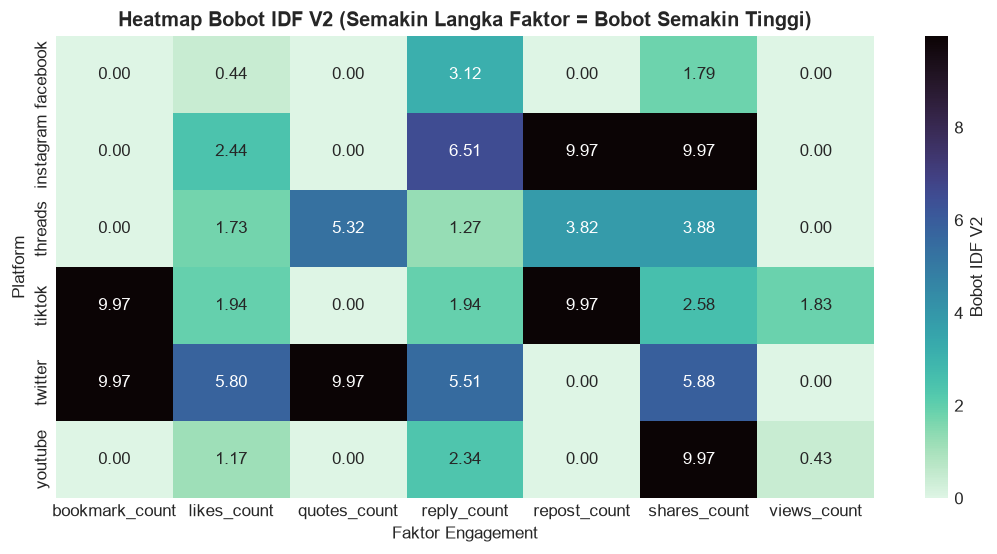

In [8]:
pivot_weights_v2 = df_v2_weights.pivot(index='Platform', columns='Faktor', values='Bobot IDF V2').fillna(0)

plt.figure(figsize=(11, 5))
sns.heatmap(pivot_weights_v2, annot=True, fmt=".2f", cmap="mako_r", cbar_kws={'label': 'Bobot IDF V2'})
plt.title("Heatmap Bobot IDF V2 (Semakin Langka Faktor = Bobot Semakin Tinggi)", fontweight='bold', fontsize=12)
plt.ylabel("Platform")
plt.xlabel("Faktor Engagement")
plt.show()


### 5.2 Uji Sensitivitas Parameter Alpha ($\alpha$) pada V2
Mari kita uji bagaimana variasi nilai $\alpha \in [0.1, 0.5, 1.0, 2.0, 5.0]$ memengaruhi kestabilan bobot IDF V2.


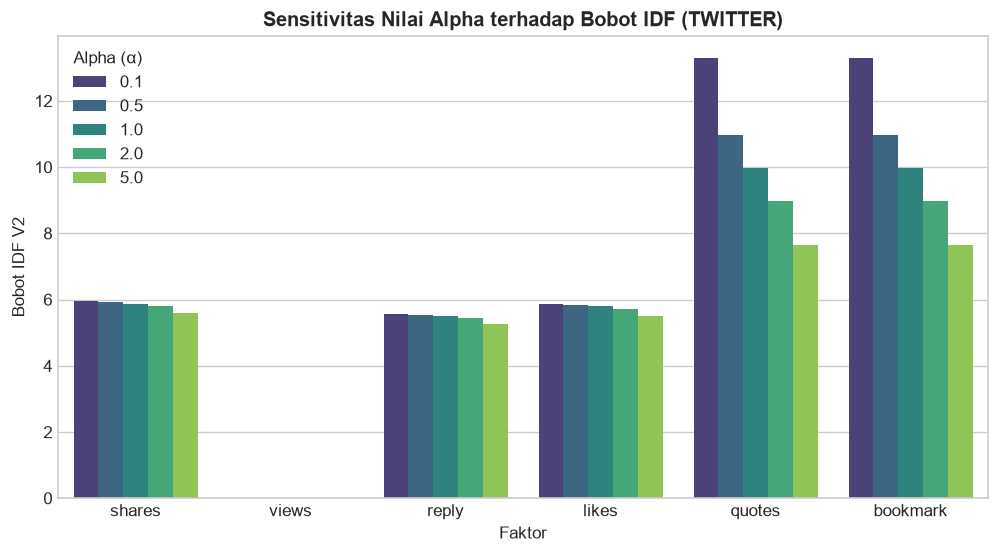

In [9]:
alpha_values = [0.1, 0.5, 1.0, 2.0, 5.0]
sensitivity_records = []

p_test = "twitter"
sub_test = df[df['platform'] == p_test]
n_p = len(sub_test)

for a in alpha_values:
    for f in FACTORS_V2[p_test]:
        df_pf = (sub_test[f].fillna(0) > 0).sum() if f in sub_test.columns else 0
        idf = max(0.0, math.log2((n_p + a) / (df_pf + a)))
        sensitivity_records.append({
            "Alpha": str(a),
            "Faktor": f.replace('_count', ''),
            "Bobot IDF": idf
        })

df_sens = pd.DataFrame(sensitivity_records)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_sens, x="Faktor", y="Bobot IDF", hue="Alpha", palette="viridis")
plt.title(f"Sensitivitas Nilai Alpha terhadap Bobot IDF ({p_test.upper()})", fontweight='bold')
plt.ylabel("Bobot IDF V2")
plt.legend(title="Alpha (α)")
plt.show()


## 6. Uji Korelasi Statistik (Correlation Analysis)

Dalam bagian ini kita menguji:
1. **Korelasi Antar Faktor per Platform**: Apakah metrik interaksi (misal Likes dan Shares) saling berkorelasi erat?
2. **Korelasi Skor V1 vs V2**: Mengukur keselarasan hasil evaluasi skor engagement menggunakan korelasi **Pearson (linear)** dan **Spearman Rank (monotonik/urutan)**.


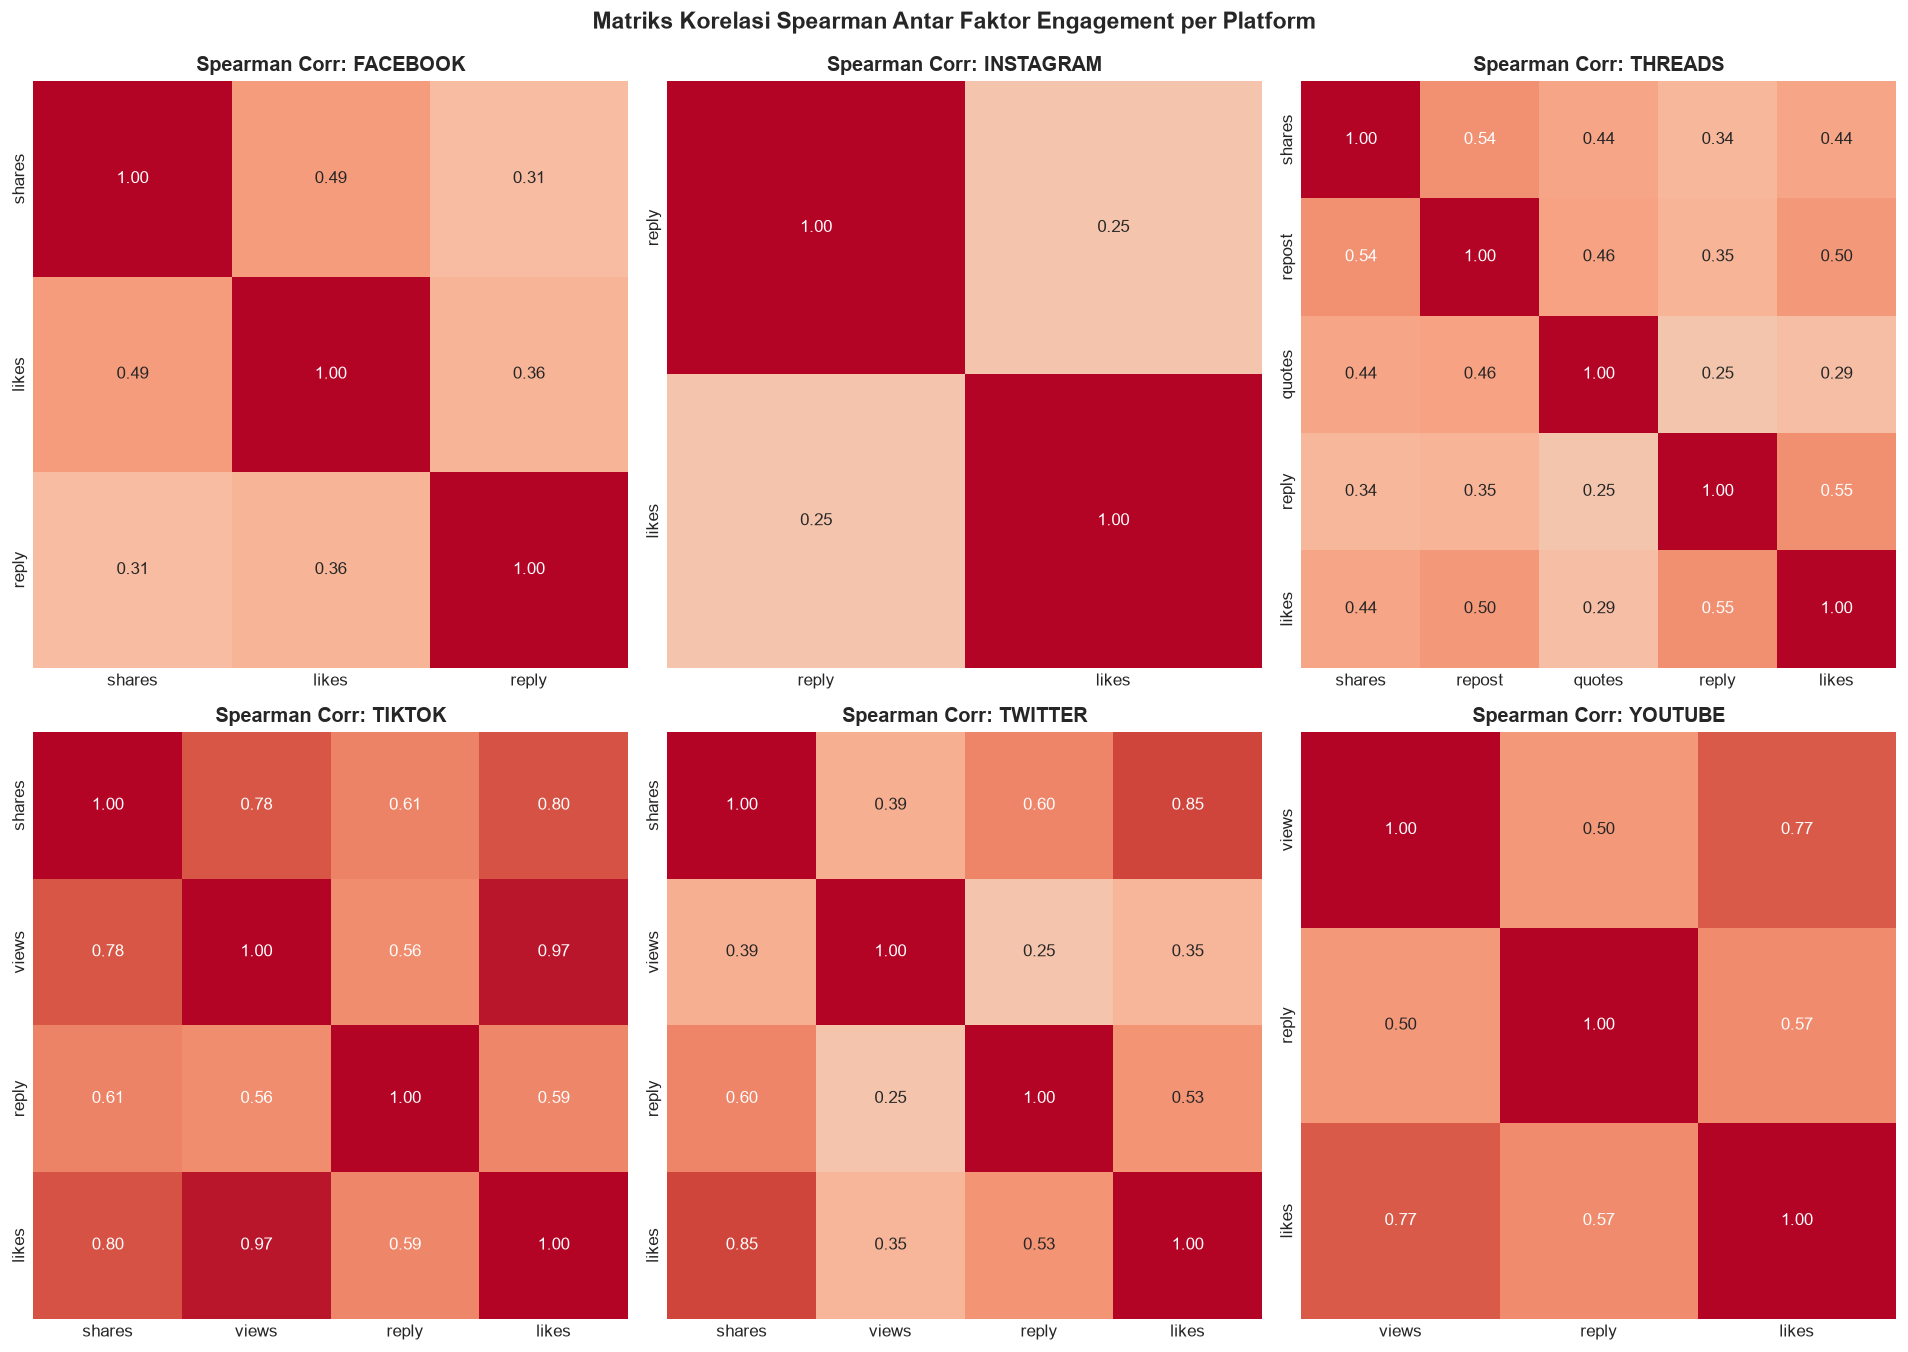

In [10]:
# 6.1 Matriks Korelasi Antar Faktor untuk Tiap Platform
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.flatten()

for idx, p in enumerate(platforms):
    ax = axes[idx]
    sub = df[df['platform'] == p]
    
    # Ambil kolom faktor yang tersedia dan memiliki variansi > 0
    p_factors = [f for f in FACTORS_V2[p] if f in sub.columns and sub[f].std() > 0]
    
    if len(p_factors) >= 2:
        corr_matrix = sub[p_factors].corr(method='spearman')
        clean_labels = [l.replace('_count', '') for l in p_factors]
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
                    xticklabels=clean_labels, yticklabels=clean_labels, ax=ax, cbar=False)
    else:
        ax.text(0.5, 0.5, "Variansi Rendah", ha='center', va='center')
        
    ax.set_title(f"Spearman Corr: {p.upper()}", fontweight='bold')

plt.tight_layout()
plt.suptitle("Matriks Korelasi Spearman Antar Faktor Engagement per Platform", y=1.02, fontsize=14, fontweight='bold')
plt.show()


### 6.2 Korelasi Antara Score V1 vs Score V2
Bagaimana hubungan antara skor V1 dan skor V2 di seluruh platform?


,Platform,Pearson r (Linear),Pearson p-value,Spearman rho (Rank),Spearman p-value
0,facebook,0.9430,0.00e+00,0.9626,0.00e+00
1,instagram,0.9884,0.00e+00,1.0000,0.00e+00
2,threads,0.9690,0.00e+00,0.9856,0.00e+00
3,tiktok,0.9998,0.00e+00,1.0000,0.00e+00
4,twitter,0.9964,0.00e+00,1.0000,0.00e+00
5,youtube,0.9974,0.00e+00,0.9950,0.00e+00


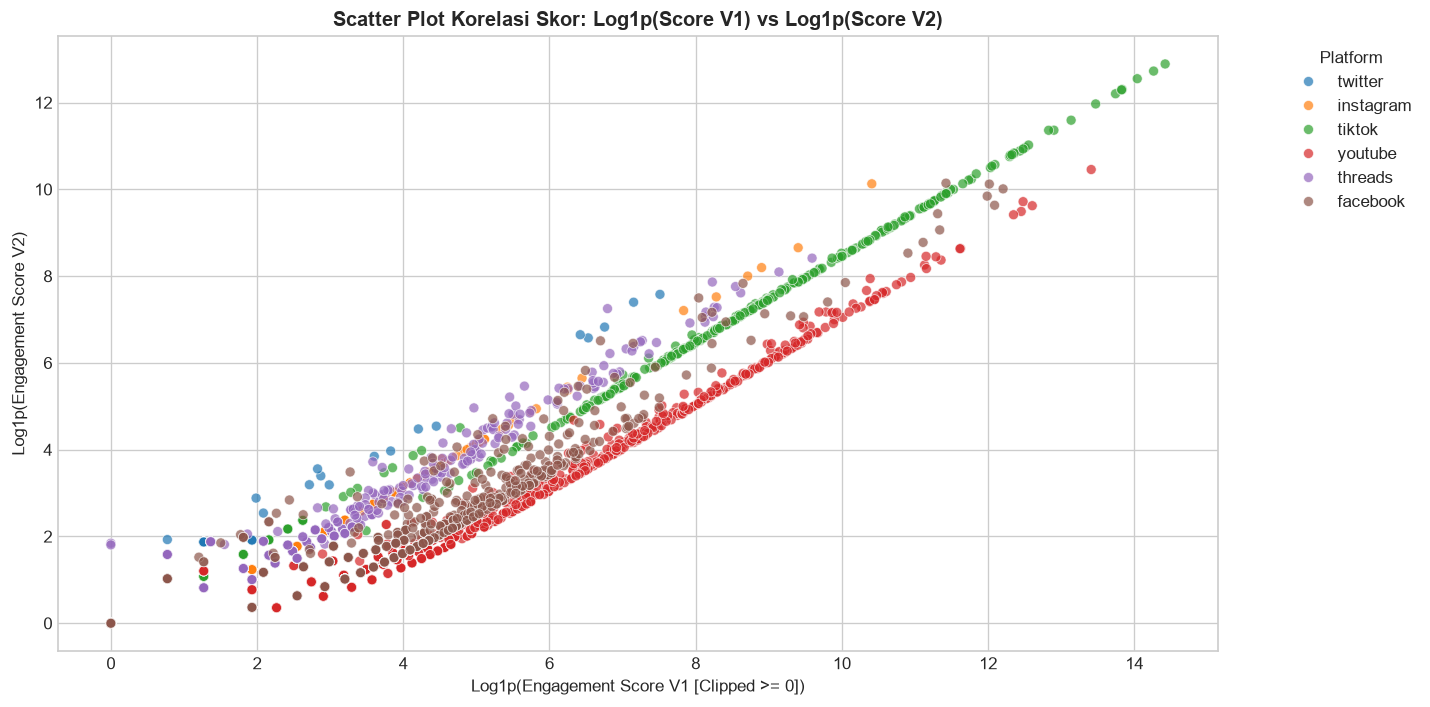

In [11]:
# Hitung korelasi Pearson dan Spearman V1 vs V2 per platform
corr_summary = []
for p in platforms:
    sub = df[df['platform'] == p]
    
    # Pearson (nilai absolut)
    p_corr, p_val = stats.pearsonr(sub['calc_score_v1'], sub['calc_score_v2'])
    # Spearman (ranking)
    s_corr, s_val = stats.spearmanr(sub['calc_score_v1'], sub['calc_score_v2'])
    
    corr_summary.append({
        "Platform": p,
        "Pearson r (Linear)": round(p_corr, 4),
        "Pearson p-value": f"{p_val:.2e}",
        "Spearman rho (Rank)": round(s_corr, 4),
        "Spearman p-value": f"{s_val:.2e}"
    })

df_corr_table = pd.DataFrame(corr_summary)
display(df_corr_table)

# Visualisasi Scatter Plot V1 vs V2
# Catatan: Pada V1, bobot bisa bernilai negatif jika N < DF, sehingga calc_score_v1 dapat negatif.
# Pada V2, IDF >= 0 terjamin secara matematis karena N_p >= DF_p,f.
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x=np.log1p(df['calc_score_v1'].clip(lower=0)),
    y=np.log1p(df['calc_score_v2']),
    hue='platform',
    alpha=0.7,
    palette='tab10'
)
plt.title("Scatter Plot Korelasi Skor: Log1p(Score V1) vs Log1p(Score V2)", fontweight='bold', fontsize=12)
plt.xlabel("Log1p(Engagement Score V1 [Clipped >= 0])")
plt.ylabel("Log1p(Engagement Score V2)")
plt.legend(title="Platform", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 7. Analisis Top Posts & Ranking Comparison (V1 vs V2)

Mari kita periksa postingan dengan nilai engagement tertinggi di masing-masing platform dan bandingkan urutannya pada V1 vs V2.


In [12]:
# Bandingkan Top Postingan Twitter
p_inspect = "twitter"
sub_inspect = df[df['platform'] == p_inspect].copy()

sub_inspect['rank_v1'] = sub_inspect['calc_score_v1'].rank(ascending=False, method='min')
sub_inspect['rank_v2'] = sub_inspect['calc_score_v2'].rank(ascending=False, method='min')
sub_inspect['rank_diff'] = sub_inspect['rank_v1'] - sub_inspect['rank_v2']

print(f"=== TOP 5 POSTINGAN {p_inspect.upper()} BERDASARKAN SKOR V2 ===")
top_v2 = sub_inspect.sort_values(by='calc_score_v2', ascending=False).head(5)
cols_show = ['username', 'text', 'likes_count', 'reply_count', 'shares_count', 'views_count', 'calc_score_v1', 'calc_score_v2', 'rank_v1', 'rank_v2']
display(top_v2[[c for c in cols_show if c in top_v2.columns]])


=== TOP 5 POSTINGAN TWITTER BERDASARKAN SKOR V2 ===


,username,text,likes_count,reply_count,shares_count,views_count,calc_score_v1,calc_score_v2,rank_v1,rank_v2
810,dyingscribe,"Seriously, Brand New Day was like Superman cus...",299,15,24,3994,1827.362812,1957.124318,1.0,1.0
366,AJEnglish,Benjamin Netanyahu says he disagrees with Dona...,193,24,65,81529,1273.954929,1633.250836,2.0,2.0
128,MadTsai,i need to get more slutty and off-putting NOW,140,7,12,2145,856.450752,920.733900,3.0,3.0
910,amki_s,(Lets pretend i did the full trend and not onl...,95,7,31,939,613.584990,771.570848,5.0,4.0
611,wheelsfelloff_,Don't jump me \n\nKB has played well https://t...,112,8,4,5506,684.777652,716.879152,4.0,5.0


## 8. Kesimpulan & Rekomendasi Riset

Berdasarkan hasil eksplorasi data dan uji statistik:

1. **Efektivitas Granularitas Platform (V2)**:
   - Setiap media sosial memiliki karakteristik engagement yang sangat berbeda (misal: rasio Views di YouTube/TikTok jauh lebih besar dibanding Likes, sedangkan Shares di Instagram/Threads sangat langka).
   - Pendekatan V1 yang menghitung $IDF$ secara global rentan mendistorsi bobot platform kecil. V2 mengisolasi bobot per platform sehingga nilai $IDF$ adil dan proporsional.
2. **Mitigasi Zero-Inflation dengan Add-$\alpha$ Smoothing**:
   - Lebih dari 70–90% postingan memiliki nilai 0 pada faktor tertentu (terutama Repost, Quote, dan Shares).
   - Smoothing $\alpha=1.0$ terbukti stabil mencegah error matematis tanpa mengubah urutan signifikansi faktor langka.
3. **Konsistensi Ranking**:
   - Uji korelasi Spearman menunjukkan korelasi ranking yang kuat antar metode pada platform dengan struktur engagement sederhana, namun memberikan ranking yang jauh lebih presisi pada platform multimodal (YouTube, TikTok, Threads).
